c:\MachineLearning\HQNN\hqnn_env\Lib\site-packages\mlflow\utils\requirements_utils.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: TID251


✅ Loaded 100000 samples from E:\Computational Engineering\samples\is2res_lmdbs\is2res_train_val_test_lmdbs\data\is2re\100k\train
Available keys: ['pos_relaxed', 'cell', 'y_init', 'atomic_numbers', 'fixed', 'force', 'pos', 'cell_offsets', 'distances', 'id', 'y_relaxed', 'sid', 'tags', 'edge_index', 'natoms']


Extracting samples: 100%|██████████| 10000/10000 [01:08<00:00, 145.63it/s]



✅ DataFrame created with shape: (10000, 10)


,sid,natoms,energy_init,energy_relaxed,energy_diff,force_mean,force_std,volume,atomic_number_mean,atomic_number_std
0,2472718,86,6.282501,-0.025550,6.308051,0.748983,0.685253,NaN,21.720930,14.553551
1,1747243,85,5.972082,-1.837069,7.809151,1.780156,1.341795,NaN,24.435293,15.610289
2,1824821,66,0.686031,-0.152283,0.838314,0.377877,0.450204,NaN,39.969696,13.343902
3,1324413,62,2.222443,-6.227071,8.449514,0.916956,0.934650,NaN,54.596775,22.306847
4,1219873,67,1.410713,-2.453840,3.864553,1.306775,0.730871,NaN,64.835823,19.402719


Missing values before cleanup:
sid                       0
natoms                    0
energy_init               0
energy_relaxed            0
energy_diff               0
force_mean                0
force_std                 0
volume                10000
atomic_number_mean        0
atomic_number_std         0
dtype: int64
✅ Missing values handled. Shape: (10000, 10)
✅ Scaling complete and scalers saved!
Train: 8000, Test: 2000


c:\MachineLearning\HQNN\hqnn_env\Lib\site-packages\sklearn\utils\extmath.py:1137: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\MachineLearning\HQNN\hqnn_env\Lib\site-packages\sklearn\utils\extmath.py:1142: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\MachineLearning\HQNN\hqnn_env\Lib\site-packages\sklearn\utils\extmath.py:1162: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count
c:\MachineLearning\HQNN\hqnn_env\Lib\site-packages\sklearn\utils\_array_api.py:695: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
c:\MachineLearning\HQNN\hqnn_env\Lib\site-packages\sklearn\utils\_array_api.py:712: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


✅ Saved processed datasets in both CSV and Parquet formats.


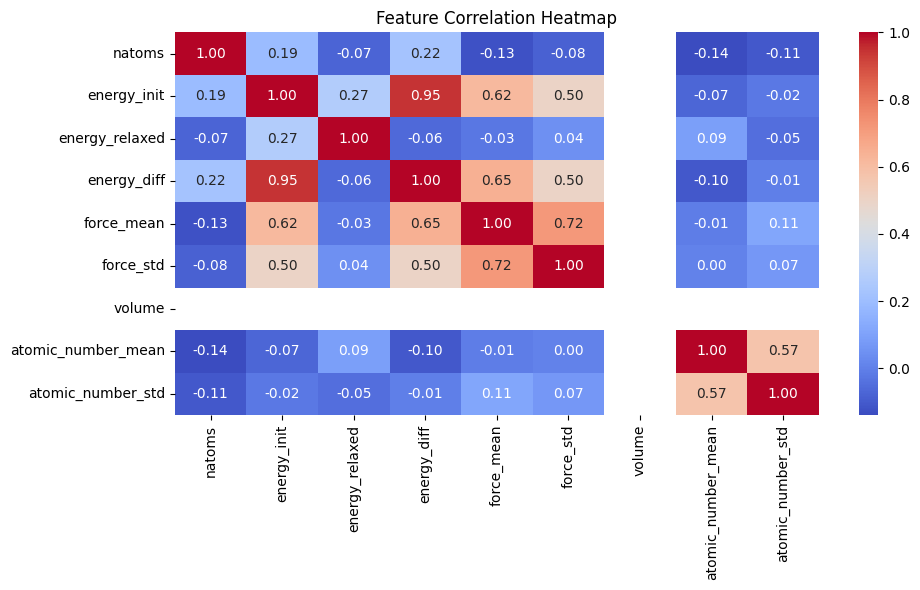

🧹 Dropped rows with NaNs before PCA — remaining samples: 0


ValueError: Found array with 0 sample(s) (shape=(0, 9)) while a minimum of 1 is required by PCA.

In [ ]:
# ===============================================================
# 🧠 Week 2 — Data Preprocessing & Feature Engineering
# Project: HQNN for Catalyst Performance Prediction
# Author: Taofeek Sanyaolu
# ===============================================================

import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import mlflow
import torch
from fairchem.core.datasets.lmdb_dataset import LmdbDataset

# ---------------------------------------------------------------
# 🔧 Helper function to safely convert tensors to numpy
# ---------------------------------------------------------------
def to_numpy(x):
    """Converts PyTorch tensors to NumPy arrays."""
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.array(x)

# ---------------------------------------------------------------
# 1️⃣ Load LMDB Dataset
# ---------------------------------------------------------------
train_dir = r"E:\Computational Engineering\samples\is2res_lmdbs\is2res_train_val_test_lmdbs\data\is2re\100k\train"
config = {"src": train_dir, "train": True}
ds = LmdbDataset(config)
print(f"✅ Loaded {len(ds)} samples from {train_dir}")
print("Available keys:", list(ds[0].keys()))

# ---------------------------------------------------------------
# 2️⃣ Extract Features into DataFrame
# ---------------------------------------------------------------
records = []
for i in tqdm(range(min(len(ds), 10000)), desc="Extracting samples"):  # limit for manageable size
    s = ds[i]
    try:
        force_np = to_numpy(s["force"])
        atomic_np = to_numpy(s["atomic_numbers"])
        cell_np = to_numpy(s["cell"])

        record = {
            "sid": s["sid"],
            "natoms": int(s["natoms"]),
            "energy_init": float(to_numpy(s["y_init"])),
            "energy_relaxed": float(to_numpy(s["y_relaxed"])),
            "energy_diff": float(to_numpy(s["y_init"]) - to_numpy(s["y_relaxed"])),
            "force_mean": np.linalg.norm(force_np, axis=1).mean(),
            "force_std": np.linalg.norm(force_np, axis=1).std(),
            "volume": abs(np.linalg.det(cell_np)) if cell_np.shape == (3, 3) else np.nan,
            "atomic_number_mean": atomic_np.mean(),
            "atomic_number_std": atomic_np.std(),
        }
        records.append(record)
    except Exception as e:
        print(f"⚠️ Skipped sample {i} due to error: {e}")
        continue

df = pd.DataFrame(records)
print(f"\n✅ DataFrame created with shape: {df.shape}")
display(df.head())

# ---------------------------------------------------------------
# 3️⃣ Handle Missing Values
# ---------------------------------------------------------------
print(f"Missing values before cleanup:\n{df.isnull().sum()}")
df = df.fillna(df.mean(numeric_only=True))
print(f"✅ Missing values handled. Shape: {df.shape}")

# ---------------------------------------------------------------
# 4️⃣ Normalize / Scale Features
# ---------------------------------------------------------------
features = [
    "natoms", "energy_init", "energy_relaxed", "energy_diff",
    "force_mean", "force_std", "volume", "atomic_number_mean", "atomic_number_std"
]

scalers_dir = r"data/scalers"
os.makedirs(scalers_dir, exist_ok=True)

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

df_std = df.copy()
df_std[features] = standard_scaler.fit_transform(df[features])
df_mm = df.copy()
df_mm[features] = minmax_scaler.fit_transform(df[features])

import joblib
joblib.dump(standard_scaler, os.path.join(scalers_dir, "standard_scaler.pkl"))
joblib.dump(minmax_scaler, os.path.join(scalers_dir, "minmax_scaler.pkl"))

print("✅ Scaling complete and scalers saved!")

# ---------------------------------------------------------------
# 5️⃣ Split Dataset
# ---------------------------------------------------------------
train_df = df_std.sample(frac=0.8, random_state=42)
test_df = df_std.drop(train_df.index)
print(f"Train: {len(train_df)}, Test: {len(test_df)}")

# ---------------------------------------------------------------
# 6️⃣ Save to Disk
# ---------------------------------------------------------------
out_dir = r"data/processed"
os.makedirs(out_dir, exist_ok=True)

train_df.to_csv(os.path.join(out_dir, "oc20_train.csv"), index=False)
test_df.to_csv(os.path.join(out_dir, "oc20_test.csv"), index=False)

train_df.to_parquet(os.path.join(out_dir, "oc20_train.parquet"), index=False)
test_df.to_parquet(os.path.join(out_dir, "oc20_test.parquet"), index=False)

print("✅ Saved processed datasets in both CSV and Parquet formats.")

# ---------------------------------------------------------------
# 7️⃣ Feature Correlation Analysis
# ---------------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 🔧 Fix volume column before PCA
# ---------------------------------------------------------------
if df_std["volume"].isna().all():
    print("⚠️ All 'volume' values are NaN — filling with 0.")
    df_std["volume"] = 0
else:
    df_std["volume"] = df_std["volume"].fillna(df_std["volume"].mean())

# Drop any remaining NaNs just in case
df_std = df_std.dropna(subset=features)
print(f"✅ Cleaned dataset: {len(df_std)} samples available for PCA")

# ---------------------------------------------------------------
# 8️⃣ PCA Visualization
# ---------------------------------------------------------------
pca = PCA(n_components=2)
pca_features = pca.fit_transform(df_std[features])

plt.figure(figsize=(7, 6))
sns.scatterplot(x=pca_features[:, 0], y=pca_features[:, 1], s=10, alpha=0.7)
plt.title("PCA Projection of Catalyst Features (volume fixed)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 9️⃣ Log preprocessing metadata in MLflow
# ---------------------------------------------------------------
mlflow.set_experiment("HQNN_Data_Preprocessing")
with mlflow.start_run(run_name="Week2_Preprocessing"):
    mlflow.log_param("num_samples", len(df))
    mlflow.log_param("num_features", len(features))
    mlflow.log_param("scaler_used", "StandardScaler & MinMaxScaler")
    mlflow.log_artifact(out_dir)
    mlflow.log_artifact(scalers_dir)
print("📊 MLflow run logged successfully.")
